In [1]:
import os
from glob import glob

import spectral_util.mosaic as mosaic
import spectral_util.spec_io as spec_io
import pyproj
from osgeo import osr, gdal
import sys
sys.path.append('/store/carroll/repos/chess-isofit/')
from utilities import cwn_to_math, edge_coords_from_target

import sys
sys.path.append('/store/carroll/repos/chess-isofit/2025/')
from data_prep import radianceH5toEnvi
import os
from glob import glob

import matplotlib.pyplot as plt

import numpy as np

import os
import re
import h5py
import numpy as np
from osgeo import gdal
import time

In [2]:
h5_filename = h5File = '/store/carroll/col/data/2025/raw/L1/radianceH5/2025_CRBU_2/2025062813/NEON_D13_CRBU_DP1_L036-1_20250628_radiance.h5'
rasterName = 'IGM_Data'
spatialIndexesToRead = None
bandIndexesToRead = None

In [3]:
f = h5py.File(h5_filename,'r')

In [4]:
f.visit(print)

CRBU
CRBU/Radiance
CRBU/Radiance/Metadata
CRBU/Radiance/Metadata/Ancillary_Rasters
CRBU/Radiance/Metadata/Coordinate_System
CRBU/Radiance/Metadata/Coordinate_System/Coordinate_System_String
CRBU/Radiance/Metadata/Coordinate_System/EPSG Code
CRBU/Radiance/Metadata/Coordinate_System/Map_Info
CRBU/Radiance/Metadata/Coordinate_System/Proj4
CRBU/Radiance/Metadata/Flight_Trajectory
CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Altitude
CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Heading
CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Time
CRBU/Radiance/Metadata/QAQC
CRBU/Radiance/Metadata/Spectral_Data
CRBU/Radiance/Metadata/Spectral_Data/FWHM
CRBU/Radiance/Metadata/Spectral_Data/Wavelength
CRBU/Radiance/RadianceDecimalPart
CRBU/Radiance/RadianceIntegerPart


In [5]:
def print_h5_tree(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"DATASET: {name}, shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"GROUP:   {name}")

f.visititems(print_h5_tree)

GROUP:   CRBU
GROUP:   CRBU/Radiance
GROUP:   CRBU/Radiance/Metadata
GROUP:   CRBU/Radiance/Metadata/Ancillary_Rasters
GROUP:   CRBU/Radiance/Metadata/Coordinate_System
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Coordinate_System_String, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/EPSG Code, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Map_Info, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Proj4, shape=(), dtype=object
GROUP:   CRBU/Radiance/Metadata/Flight_Trajectory
DATASET: CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Altitude, shape=(90843, 1), dtype=float32
DATASET: CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Heading, shape=(90843, 1), dtype=float32
DATASET: CRBU/Radiance/Metadata/Flight_Trajectory/Flight_Time, shape=(90843, 1), dtype=float64
GROUP:   CRBU/Radiance/Metadata/QAQC
GROUP:   CRBU/Radiance/Metadata/Spectral_Data
DATASET: CRBU/Radiance/Metadata/Spectral_Data/FWHM, shape=(4

In [6]:
with h5py.File('/store/carroll/col/data/2025/raw/L1/radianceH5/2025_CRBU_2/2025062813/NEON_D13_CRBU_DP1_L035-1_20250628_radiance.h5', 'r') as f:
    f.visititems(print_h5_tree)


GROUP:   CRBU
GROUP:   CRBU/Radiance
GROUP:   CRBU/Radiance/Metadata
GROUP:   CRBU/Radiance/Metadata/Ancillary_Rasters
DATASET: CRBU/Radiance/Metadata/Ancillary_Rasters/BDE, shape=(598, 426), dtype=uint8
DATASET: CRBU/Radiance/Metadata/Ancillary_Rasters/GLT_Data, shape=(25680, 1563, 2), dtype=float32
DATASET: CRBU/Radiance/Metadata/Ancillary_Rasters/IGM_Data, shape=(25680, 1563, 3), dtype=float32
DATASET: CRBU/Radiance/Metadata/Ancillary_Rasters/OBS_Data, shape=(25680, 1563, 11), dtype=float32
GROUP:   CRBU/Radiance/Metadata/Coordinate_System
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Coordinate_System_String, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/EPSG Code, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Map_Info, shape=(), dtype=object
DATASET: CRBU/Radiance/Metadata/Coordinate_System/Proj4, shape=(), dtype=object
GROUP:   CRBU/Radiance/Metadata/Flight_Trajectory
DATASET: CRBU/Radiance/Metadata/Flight_Trajectory/Fligh

In [7]:
raster, metadata = radianceH5toEnvi.h5refl2array(h5File, rasterName, spatialIndexesToRead = spatialIndexesToRead, bandIndexesToRead = bandIndexesToRead )

KeyError: "Unable to synchronously open object (object 'IGM_Data' doesn't exist)"

In [2]:
os.chdir('/store/carroll/col/data/2025/')
outDir = 'raw/L1/radianceENVI/'
h5_dir = 'raw/L1/radianceH5/'
# h5_files = glob(os.path.join(h5_dir, '*/*/*.h5'))
h5_files = ['raw/L1/radianceH5/2025_UPTA_1/2025071213/NEON_D13_UPTA_DP1_L034-1_20250712_radiance.h5']
h5File = h5_files[0]

filePathToEnviProjCs = '/store/shared/ENVI6/envi61/idl/resource/pedata/predefined/EnviPEProjcsStrings.txt'

rasterNames = ['Radiance']
rasterName = rasterNames[0]

In [ ]:
for h5_filename in h5_files:
    print(h5_filename)
    for rasterName in rasterNames:
        outFile = os.path.join(outDir,os.path.basename(h5_filename).replace('radiance.h5','rdn'))
        print(outFile)
        try:
            radianceH5toEnvi.convertH5RasterToEnvi(h5_filename, rasterName, outFile, filePathToEnviProjCs)
            print('success', outFile)
        except:
            print('failed', outFile)

In [ ]:
def convertH5RasterToEnvi(h5File,rasterName,outEnviFile,filePathToEnviProjCs,spatialIndexesToRead = None,bandIndexesToRead = None):

    raster, metadata = h5refl2array(h5File, rasterName,spatialIndexesToRead = spatialIndexesToRead, bandIndexesToRead = bandIndexesToRead )

In [ ]:
spatialIndexesToRead = None
bandIndexesToRead = None
raster, metadata = radianceH5toEnvi.h5refl2array(h5File, rasterName,spatialIndexesToRead = spatialIndexesToRead, bandIndexesToRead = bandIndexesToRead )

In [ ]:
fps_h5 = glob('raw/L1/radianceH5/*/*/.h5')

In [ ]:
fid = 'NIS01_20250712_145512_UPTA'

# visualize rdn, 
working_dir = f'2018/deploy_6c_20251229/{fid}'
fp = glob(os.path.join(working_dir, 'output', f'{test_fid}_atm_interp.hdr'))[0]
rgb = envi.open(fp).open_memmap().copy()
rgb.shape

fig, axs = plt.subplots(ncols=3, figsize=(10,20))

p0 = axs[0].imshow(rgb[...,0])
fig.colorbar(p0, ax=axs[0])

p1 = axs[1].imshow(rgb[...,1])
fig.colorbar(p1, ax=axs[1])

p2 = axs[2].imshow(rgb[...,2])
fig.colorbar(p2, ax=axs[2])

plt.show()

In [178]:
fid = 'NIS01_20250712_151338_UPTA'

In [163]:
fp = '/store/carroll/repos/chess-isofit/2025/6c/3_shade/failed_shade_fids.txt'
with open(fp, 'r') as f:
    fids = [x.strip() for x in f.readlines()]
fid = fids[0]
fid

'NIS01_20250702_162640_CRBU'

In [164]:
solar_azimuth_band = 4
solar_zenith_band = 5
output_folder = '/store/carroll/col/data/2018/shade'

In [165]:
obs_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_OBS_Data')[0]
dsm_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_IGM_Data')[0]
output_file = os.path.join(output_folder, f'{fid}_shade.tif')

In [166]:
obs_set = gdal.Open(obs_file, gdal.GA_ReadOnly)
solar_azimuth = obs_set.GetRasterBand(solar_azimuth_band).ReadAsArray()
solar_zenith = obs_set.GetRasterBand(solar_zenith_band).ReadAsArray()
dsm = gdal.Open(dsm_file, gdal.GA_ReadOnly).ReadAsArray()[2,...]

bounds = (0, 0, solar_azimuth.shape[1] - 1, solar_azimuth.shape[0] - 1)

In [167]:
solar_azimuth.shape, dsm.shape

((28070, 2208), (28070, 2208))

In [168]:
valid = dsm>=0
valid_loc = np.where(valid)

In [169]:
target_px_x = valid_loc[1]
target_px_y = valid_loc[0]
angle = cwn_to_math(solar_azimuth[valid])
target_px_x.shape, target_px_y.shape, angle.shape, bounds

((18824824,), (18824824,), (18824824,), (0, 0, 2207, 28069))

In [170]:
dy = np.sin(np.deg2rad(angle))  
dx = np.cos(np.deg2rad(angle))  
dy.shape, dx.shape

((18824824,), (18824824,))

In [171]:
np.min(solar_azimuth[valid]), np.max(solar_azimuth[valid]), np.median(solar_azimuth[valid])

(101.29036, 102.66733, 101.957726)

In [172]:
np.min(angle), np.max(angle), np.mean(angle)

(347.33267, 348.70966, 348.03888)

In [173]:
invert = np.zeros_like(angle, dtype=bool)
invert[np.logical_and(angle > 180, angle < 360)] = True
invert[np.logical_and(angle < 0, angle > -180)] = True
invert.shape

(18824824,)

In [174]:
len(invert[invert==True]), len(invert[invert==False])

(18824824, 0)

In [144]:
xdelta = np.ones_like(angle, dtype=int) * target_px_x
ydelta = np.ones_like(angle, dtype=int) * target_px_y
xdelta.shape, ydelta.shape

((19340410,), (19340410,))

In [80]:
tmp = xdelta[invert]
tmp.shape

(8344062,)

In [175]:
bounds

(0, 0, 2207, 28069)

In [176]:
dsm.shape

(28070, 2208)

In [145]:
if np.any(invert):
    print('inverting')
    xdelta[invert] = bounds[2] - target_px_x
    ydelta[invert] = bounds[3] - target_px_y
    xdelta[invert] *= -1
    ydelta[invert] *= -1

In [85]:
tmp = solar_azimuth[valid]
tmp.shape

(10984169,)

In [86]:
np.min(tmp), np.max(tmp)

(89.75602, 90.71372)

In [66]:
np.min(tmp), np.max(tmp)

(86.77018, 88.1232)

In [ ]:
def edge_coords_from_target(target_px_x: np.array, target_px_y: np.array, angle: np.array, bounds):
    """ Get the coordinates of the edge pixel in the direction of the given angle from a target pixel.

    Args:
        target_px_x (array, int): array of x-coordinate of the target pixel.
        target_px_y (array, int): array of y-coordinate of the target pixel.
        angle (array, float): angle in degrees, clockwise from North.
        bounds (tuple): bounds of the image in the format (min_x, min_y, max_x, max_y).
    """

    # Compute direction vector (dx, dy) in image coordinates
    dy = np.sin(np.deg2rad(angle))  
    dx = np.cos(np.deg2rad(angle))  
    #dy = -dy  # Invert y direction for image coordinates

    invert = np.zeros_like(angle, dtype=bool)
    invert[np.logical_and(angle > 180, angle < 360)] = True
    invert[np.logical_and(angle < 0, angle > -180)] = True

    xdelta = np.ones_like(angle, dtype=int) * target_px_x
    ydelta = np.ones_like(angle, dtype=int) * target_px_y

    if np.any(invert):
        print('inverting')
        xdelta[invert] = bounds[2] - target_px_x
        ydelta[invert] = bounds[3] - target_px_y
        xdelta[invert] *= -1
        ydelta[invert] *= -1

    # There will be two candidate edges, one on the x-axis, and one the y-axis.
    # Start by finding both
    edge_px_horizontal_y = np.zeros_like(angle, dtype=int) 
    if np.any(invert):
        edge_px_horizontal_y[invert] = bounds[3]
    edge_px_horizontal_x = dx / dy * ydelta  + target_px_x

    edge_px_vertical_x = np.zeros_like(angle, dtype=int)
    if np.any(invert):
        edge_px_vertical_x[invert] = bounds[2]
    edge_px_vertical_y = dy / dx * xdelta + target_px_y

    vertical_select = np.logical_or.reduce((
        edge_px_horizontal_x < bounds[0],
        edge_px_horizontal_x > bounds[2],
        edge_px_horizontal_y < bounds[1],
        edge_px_horizontal_y > bounds[3]
    ))

    edge_px_x_out = edge_px_horizontal_x.copy()
    edge_px_y_out = edge_px_horizontal_y.copy()
    edge_px_x_out[vertical_select] = edge_px_vertical_x[vertical_select]
    edge_px_y_out[vertical_select] = edge_px_vertical_y[vertical_select]
    slope = dy / dx
    return edge_px_x_out, edge_px_y_out, slope

In [26]:
valid = dsm>=0
valid_loc = np.where(valid)

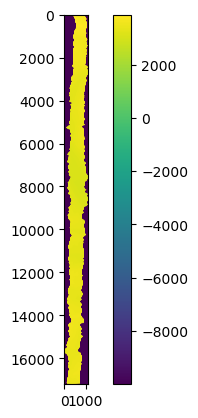

In [35]:
fig = plt.figure()
plt.imshow(dsm)
plt.colorbar()
plt.show()

In [36]:
solar_edge_px_x, solar_edge_px_y, _ = edge_coords_from_target(valid_loc[1], valid_loc[0], cwn_to_math(solar_azimuth[valid]), bounds)

inverting


ValueError: NumPy boolean array indexing assignment cannot assign 10984169 input values to the 8344062 output values where the mask is true

In [ ]:
# adapted directly from https://github.com/emit-sds/emit-sds-masks/blob/develop/cloud_shade.py and https://github.com/pgbrodrick/shade-ray-trace/blob/master/calculate_shade.py

import numpy as np
import bresenham_line
from tqdm import tqdm
import argparse
from glob import glob
import os

import sys
sys.path.append('/store/carroll/repos/chess-isofit/')
from utilities import cwn_to_math, edge_coords_from_target

# set up parser so flight id submitted from batch script
parser = argparse.ArgumentParser()
parser.add_argument("--fid", required=True)
parser.add_argument("--solar_azimuth_band", type=int, required=True)
parser.add_argument("--solar_zenith_band", type=int, required=True)
parser.add_argument("--output_folder", required=True)
args = parser.parse_args()
fid = args.fid
solar_azimuth_band = args.solar_azimuth_band
solar_zenith_band = args.solar_zenith_band
output_folder = args.output_folder

print(fid)

# define inputs
if '2018' in fid:
    obs_file = glob(f'/store/carroll/col/data/2018/raw/L1/*/{fid}_rdn_obs_ort')[0]
    dsm_file = glob(f'/store/carroll/col/data/2018/raw/L1/*/{fid}_rdn_ort_igm_ort')[0]
elif '2025' in fid:
    obs_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_OBS_Data')[0]
    dsm_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_IGM_Data')[0]
output_file = os.path.join(output_folder, f'{fid}_shade.tif')

if os.path.exists(output_file)==False:
    obs_set = gdal.Open(obs_file, gdal.GA_ReadOnly)
    solar_azimuth = obs_set.GetRasterBand(solar_azimuth_band).ReadAsArray()
    solar_zenith = obs_set.GetRasterBand(solar_zenith_band).ReadAsArray()
    dsm = gdal.Open(dsm_file, gdal.GA_ReadOnly).ReadAsArray()[2,...]

    bounds = (0, 0, solar_azimuth.shape[1] - 1, solar_azimuth.shape[0] - 1)

    # identify coordinates of all valid target pixels
    valid = dsm>=0
    valid_loc = np.where(valid)

    # identify the coordinates of the solar edge pixel for each target pixel
    solar_edge_px_x, solar_edge_px_y, _ = edge_coords_from_target(valid_loc[1], valid_loc[0], cwn_to_math(solar_azimuth[valid]), bounds)

    # set up output shade mask
    shade_mask = np.ones_like(solar_azimuth)
    shade_mask[:] = -9999

    # for each target pixel, 
    for _l in tqdm(range(len(valid_loc[0]))):
        # identify target, edge px coordinates
        target_px = np.array([valid_loc[1][_l], valid_loc[0][_l]]).reshape(1,-1)
        edge_px = np.array([solar_edge_px_x[_l], solar_edge_px_y[_l]]).reshape(1,-1)

        # caluclate bresenham line - identify the coordinates of all px in a straight line from the the target to edge px
        linepx = bresenham_line.bresenhamline(target_px, edge_px, max_iter=-1)

        # subset to valid px in line
        valid = linepx[:,0] < bounds[2]
        valid[linepx[:,1] >= bounds[3]] = False
        linepx = linepx[valid,:]

        # calculate [horizontal] distance from target px for each point on the bresenham line
        px_dist = np.sqrt((linepx[:,0] - target_px[0,0])**2 + (linepx[:,1] - target_px[0,1])**2)

        # get the dsm value at each point on the bresenham line
        surface_line = dsm[linepx[:, 1], linepx[:, 0]]
        surface_line[np.isfinite(surface_line) == False] = -9999
        
        # calculate the height of the solar ray at each point on the line
        solar_height = dsm[target_px[0,1], target_px[0,0]] + px_dist * np.tan(np.pi / 180 * (90-solar_zenith[target_px[0,1], target_px[0,0]]))
        
        # the pixel is sunlit if the solar height is always higher than the surface (IE, no ray intersection)
        sunlit = np.all(solar_height > surface_line)
        shade_mask[target_px[0,1], target_px[0,0]] = sunlit

    driver = gdal.GetDriverByName('GTiff')
    outDataset = driver.Create(output_file, obs_set.RasterXSize, obs_set.RasterYSize, 1, gdal.GDT_Float32, ['COMPRESS=LZW'])
    outDataset.SetGeoTransform(obs_set.GetGeoTransform())
    outDataset.SetProjection(obs_set.GetProjection())
    outDataset.GetRasterBand(1).WriteArray(shade_mask, 0, 0)

'NIS01_20250712_151338_UPTA'

In [17]:
for fid in fids:
    print(fid)
    obs_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_OBS_Data')[0]
    dsm_file = glob(f'/store/carroll/col/data/2025/raw/L1/radianceENVI/{fid}_*_IGM_Data')[0]
    print(obs_file, os.path.exists(obs_file))
    print(dsm_file, os.path.exists(dsm_file))

NIS01_20250702_162640_CRBU
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250702_162640_CRBU_DP1_L064-1_OBS_Data True
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250702_162640_CRBU_DP1_L064-1_IGM_Data True
NIS01_20250614_175657_ALMO
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250614_175657_ALMO_DP1_L043-2_OBS_Data True
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250614_175657_ALMO_DP1_L043-2_IGM_Data True
NIS01_20250614_182911_ALMO
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250614_182911_ALMO_DP1_L058-1_OBS_Data True
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250614_182911_ALMO_DP1_L058-1_IGM_Data True
NIS01_20250712_145512_UPTA
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250712_145512_UPTA_DP1_L034-1_OBS_Data True
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250712_145512_UPTA_DP1_L034-1_IGM_Data True
NIS01_20250712_151338_UPTA
/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20

In [15]:
ul_lr_list="/store/carroll/col/data/2025/mosaic/file_lists/ul_lr_grids_CRBU.txt"
all_obs_files="/store/carroll/col/data/2025/mosaic/file_lists/top_priority_obs_CRBU.txt"
deprioritize_file_list="/store/carroll/col/data/2025/mosaic/file_lists/deprioritize_obs.txt"

input_file_list = all_obs_files
ignore_file_list = None
output_epsg=32613
x_resolution=1
y_resolution=-1

target_extent_ul_lr = [316043.52434115, 4326501.814591583, 320258.1645610586, 4320589.097705487]

In [6]:
if input_file_list.endswith(".nc"):
    input_files = [input_file_list]
else:
    input_files = [x.strip() for x in open(input_file_list, 'r').readlines()]

ignore_files = []
if ignore_file_list is not None:
    ignore_files = [x.strip() for x in open(ignore_file_list, 'r').readlines()]

deprioritize_files = []
if deprioritize_file_list is not None:
    deprioritize_files = [x.strip() for x in open(deprioritize_file_list, 'r').readlines()]

In [8]:
deprioritize_files

['/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250628_155528_CRBU_DP1_L034-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_153839_CRBU_DP1_L043-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_154915_CRBU_DP1_L044-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_160003_CRBU_DP1_L045-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_161038_CRBU_DP1_L046-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_162123_CRBU_DP1_L047-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250629_163144_CRBU_DP1_L048-1_OBS_Data',
 '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250702_162640_CRBU_DP1_L064-1_OBS_Data']

In [17]:
gproj = osr.SpatialReference()
gproj.ImportFromEPSG(int(output_epsg))
wkt = gproj.ExportToWkt()
proj = pyproj.Proj(f"epsg:{output_epsg}")

if target_extent_ul_lr:
    ul_lr = target_extent_ul_lr # in output epsg projection
else:
    # Always gets this in 4326
    ul_lr = mosaic.get_ul_lr_from_files(input_files, get_resolution=False)
    # convert to output epsg
    ul = proj(ul_lr[0], ul_lr[1])
    lr = proj(ul_lr[2], ul_lr[3])
    ul_lr = [ul[0], ul[1], lr[0], lr[1]]

ul_lr

[316043.52434115, 4326501.814591583, 320258.1645610586, 4320589.097705487]

In [20]:
trans = [ul_lr[0] - x_resolution/2., x_resolution, 0, 
         ul_lr[1] - y_resolution/2., 0, y_resolution]
meta = spec_io.GenericGeoMetadata(['GLT X', 'GLT Y', 'File Index', 'OBS val'], 
                                  projection=wkt, 
                                  geotransform=trans, 
                                  pre_orthod=True, 
                                  nodata_value=0)

glt = np.zeros(( int(np.ceil((ul_lr[3] - ul_lr[1]) / y_resolution)), 
                 int(np.ceil((ul_lr[2] - ul_lr[0]) / x_resolution)),
                 3), dtype=np.int32)
criteria = np.zeros((glt.shape[0], glt.shape[1]), dtype=np.float32)
criteria[...] = np.nan

y_grid_steps = np.arange(ul_lr[1], ul_lr[3] - trans[5]*0.01,trans[5])
x_grid_steps = np.arange(ul_lr[0], ul_lr[2] - trans[1]*0.01,trans[1])
y_grid, x_grid = np.meshgrid(y_grid_steps, 
                             x_grid_steps,
                             indexing='ij')

In [21]:
file = '/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250628_155528_CRBU_DP1_L034-1_OBS_Data'
file

'/store/carroll/col/data/2025/raw/L1/radianceENVI/NIS01_20250628_155528_CRBU_DP1_L034-1_OBS_Data'

In [22]:
if file in ignore_files:
    print('ignore')